<a href="https://colab.research.google.com/github/Prernakishore/Prernakishore/blob/main/Advance_bank_term_deposit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [1]:
from google.colab import files
upload = files.upload()

Saving bankmarketing.csv to bankmarketing.csv


In [2]:
import pandas as pd
df=pd.read_csv("bankmarketing.csv")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
#Viewing the data structure of data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [4]:
#THE SHAPE OF THE DATASET
df.shape

(41188, 21)

In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [5]:
 df.duplicated().sum()

np.int64(12)

In [ ]:
df['y'].value_counts
df['y'].value_counts(normalize=True) *100

,proportion
y,
no,88.734583
yes,11.265417


In [6]:
df=df.drop_duplicates()

In [7]:
for col in df.select_dtypes(include='object').columns:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        print(col, ":", count)

job : 330
marital : 80
education : 1730
default : 8596
housing : 990
loan : 990


In [ ]:
for col in df.select_dtypes(include='object').columns:
  print("\n", col)
  print(df[col].unique())


 job
['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']

 marital
['married' 'single' 'divorced' 'unknown']

 education
['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']

 default
['no' 'unknown' 'yes']

 housing
['no' 'yes' 'unknown']

 loan
['no' 'yes' 'unknown']

 contact
['telephone' 'cellular']

 month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']

 day_of_week
['mon' 'tue' 'wed' 'thu' 'fri']

 poutcome
['nonexistent' 'failure' 'success']

 y
['no' 'yes']


In [ ]:
for col in df.select_dtypes(include='object').columns:
  print("\n---",col,"---")
  print(df[col].value_counts())


--- job ---
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

--- marital ---
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

--- education ---
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

--- default ---
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

--- housing ---
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

--- loan ---
loan
no         33950
yes         6248
unknown      9

In [8]:
#SUMMARY STATISTICS OF THE DATA SET
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41176.0,40.023800,10.420680,17.000,32.000,38.000,47.000,98.000
duration,41176.0,258.315815,259.305321,0.000,102.000,180.000,319.000,4918.000
campaign,41176.0,2.567879,2.770318,1.000,1.000,2.000,3.000,56.000
pdays,41176.0,962.464810,186.937102,0.000,999.000,999.000,999.000,999.000
previous,41176.0,0.173013,0.494964,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41176.0,0.081922,1.570883,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41176.0,93.575720,0.578839,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41176.0,-40.502863,4.627860,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41176.0,3.621293,1.734437,0.634,1.344,4.857,4.961,5.045
nr.employed,41176.0,5167.034870,72.251364,4963.600,5099.100,5191.000,5228.100,5228.100


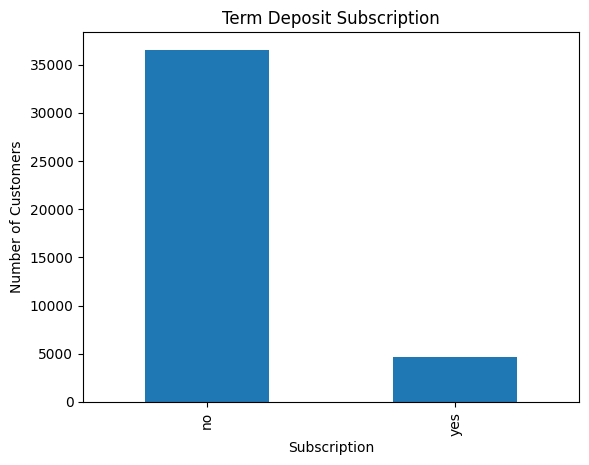

In [ ]:
import matplotlib.pyplot as plt
df['y'].value_counts().plot(kind='bar')

plt.title('Term Deposit Subscription')
plt.xlabel('Subscription')
plt.ylabel('Number of Customers')
plt.show()


The majority customers did not subscribe to the term deposit.

In [ ]:
job_subscription = pd.crosstab(
    df['job'], df['y'], normalize='index'
    )*100

job_subscription

y,no,yes
job,,
admin.,87.033305,12.966695
blue-collar,93.104939,6.895061
entrepreneur,91.483516,8.516484
housemaid,90.000000,10.000000
management,88.782490,11.217510
retired,74.738068,25.261932
self-employed,89.514426,10.485574
services,91.857827,8.142173
student,68.571429,31.428571


Students and retired customers have relatively higher subscription rates, while blue-collar customers have the lowest subscription rates among the listed job categories.

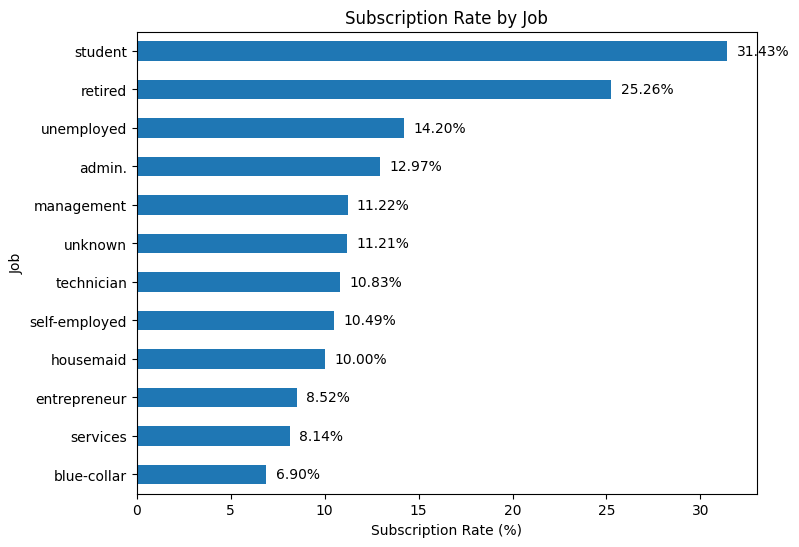

In [ ]:
import matplotlib.pyplot as plt

sorted_values = job_subscription['yes'].sort_values()

ax = sorted_values.plot(
    kind='barh',
    figsize=(8, 6)
)

plt.title('Subscription Rate by Job')
plt.xlabel('Subscription Rate (%)')
plt.ylabel('Job')

for i, value in enumerate(sorted_values):
    ax.text(value + 0.5, i, f'{value:.2f}%', va='center')

plt.show()

Students have the highest subscription rate (31.43%), followed by retired customers(25.26%). Blue-collar customers have the most the lowest subscription rate(6.90%). So, this suggests job category may be an important factor associated with term-deposit subscription behaviour.

In [ ]:
  education_subscription = pd.crosstab(
    df['education'],
    df['y'],
    normalize='index'
) * 100

education_subscription

y,no,yes
education,,
basic.4y,89.750958,10.249042
basic.6y,91.793976,8.206024
basic.9y,92.175352,7.824648
high.school,89.161060,10.838940
illiterate,77.777778,22.222222
professional.course,88.645038,11.354962
university.degree,86.279184,13.720816
unknown,85.491329,14.508671


In [ ]:
  marital_subscription = pd.crosstab(
         df['marital'],df['y'],
         normalize='index') *100

marital_subscription



y,no,yes
marital,,
divorced,89.679098,10.320902
married,89.842747,10.157253
single,85.995851,14.004149
unknown,85.000000,15.000000


single customers having a relatively higher subscription rate.


In [ ]:
housing_subscription=pd.crosstab(
    df['housing'],df['y'],normalize='index') *100

housing_subscription

y,no,yes
housing,,
no,89.120395,10.879605
unknown,89.191919,10.808081
yes,88.380608,11.619392


In [ ]:
loan_subscription=pd.crosstab(
    df['loan'],df['y'],normalize= 'index')*100

loan_subscription

y,no,yes
loan,,
no,88.659794,11.340206
unknown,89.191919,10.808081
yes,89.068502,10.931498


In [ ]:
default_subscription = pd.crosstab(
    df['default'],
    df['y'],
    normalize='index'
) * 100

default_subscription

y,no,yes
default,,
no,87.121026,12.878974
unknown,94.847040,5.152960
yes,100.000000,0.000000


In [ ]:
contact_subscription = pd.crosstab(
    df['contact'],
    df['y'],
    normalize='index'
) * 100

contact_subscription


y,no,yes
contact,,
cellular,85.262393,14.737607
telephone,94.768679,5.231321


Customers contacted through cellular had a subscription rate of 14.74%, compared with 5.23% for customers contacted through telephone.



In [ ]:
month_subscription= pd.crosstab(
    df['month'],
    df['y'], normalize='index')*100

month_subscription


y,no,yes
month,,
apr,79.521277,20.478723
aug,89.397863,10.602137
dec,51.098901,48.901099
jul,90.953443,9.046557
jun,89.488530,10.511470
mar,49.450549,50.549451
may,93.565255,6.434745
nov,89.856133,10.143867
oct,56.128134,43.871866


In [ ]:
day_subscription = pd.crosstab(
    df['day_of_week'],
    df['y'],
    normalize='index'
) * 100

day_subscription


y,no,yes
day_of_week,,
fri,89.191261,10.808739
mon,90.051680,9.948320
thu,87.881248,12.118752
tue,88.220025,11.779975
wed,88.332924,11.667076


In [ ]:
poutcome_subscription = pd.crosstab(
    df['poutcome'],
    df['y'],
    normalize='index'
) * 100

poutcome_subscription

y,no,yes
poutcome,,
failure,85.771402,14.228598
nonexistent,91.167787,8.832213
success,34.887109,65.112891


Customers with a successful previous campaign had a much higher subscription rate (65.11%) compared with customers with a failed previous campaign (14.23%) or no previous campaign outcome (8.83%).

In [ ]:
#Numerical analysis
df.select_dtypes(include='number').columns


Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

In [ ]:
df.groupby('y')['age'].mean()

,age
y,
no,39.910994
yes,40.912266


In [ ]:
df.groupby('y')['age'].median()

,age
y,
no,38.0
yes,37.0


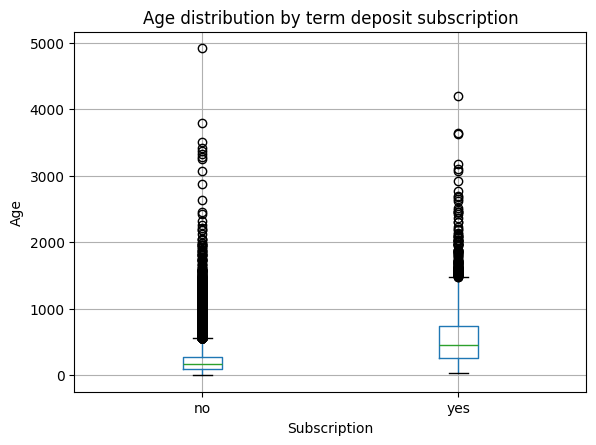

In [ ]:
import matplotlib.pyplot as plt
df.boxplot(column='duration',by='y')
plt.title('Age distribution by term deposit subscription')
plt.suptitle('')
plt.xlabel('Subscription')
plt.ylabel('Age')
plt.show()


In [ ]:
#Checking duration analysis on subscription
df.groupby('y')['duration'].mean()

,duration
y,
no,220.868079
yes,553.256090


In [ ]:
df.groupby('y')['duration'].median()

,duration
y,
no,164.0
yes,449.0


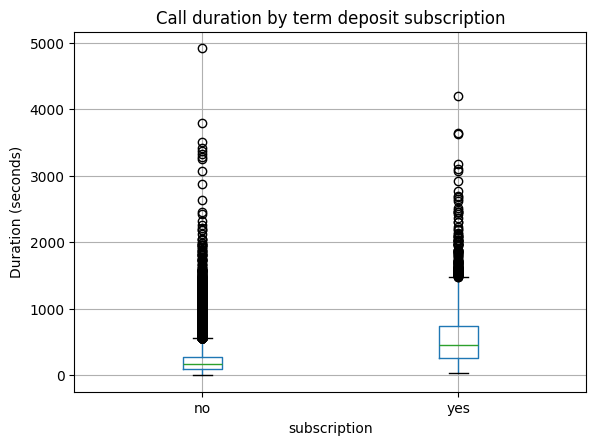

In [ ]:
df.boxplot(column='duration', by='y')
plt.title('Call duration by term deposit subscription')
plt.suptitle('')
plt.xlabel('subscription')
plt.ylabel('Duration (seconds)')
plt.show()

In [ ]:
df.groupby('y')['campaign'].mean()


,campaign
y,
no,2.633385
yes,2.051951


In [ ]:
df.groupby('y')['campaign'].median()

,campaign
y,
no,2.0
yes,2.0


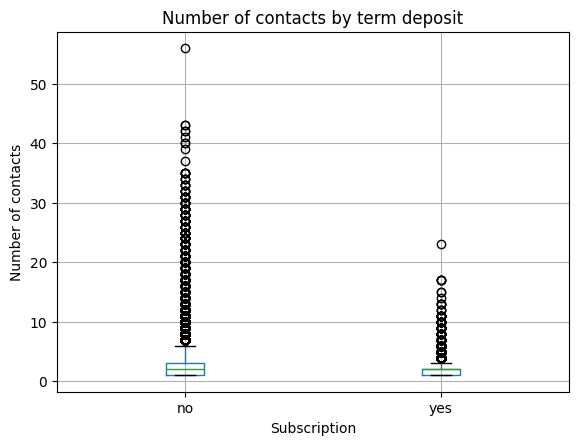

In [ ]:
df.boxplot(column='campaign',by='y')
plt.title('Number of contacts by term deposit')
plt.suptitle('')
plt.xlabel('Subscription')
plt.ylabel('Number of contacts')
plt.show()

In [ ]:
df.groupby('y')['previous'].mean()

,previous
y,
no,0.132414
yes,0.492779


In [ ]:
df.groupby('y')['previous'].median()

,previous
y,
no,0.0
yes,0.0


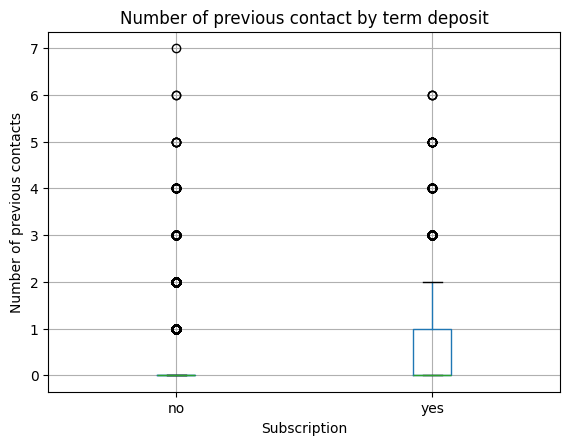

In [ ]:
df.boxplot(column='previous',by='y')
plt.title('Number of previous contact by term deposit')
plt.suptitle('')
plt.xlabel('Subscription')
plt.ylabel('Number of previous contacts')
plt.show()

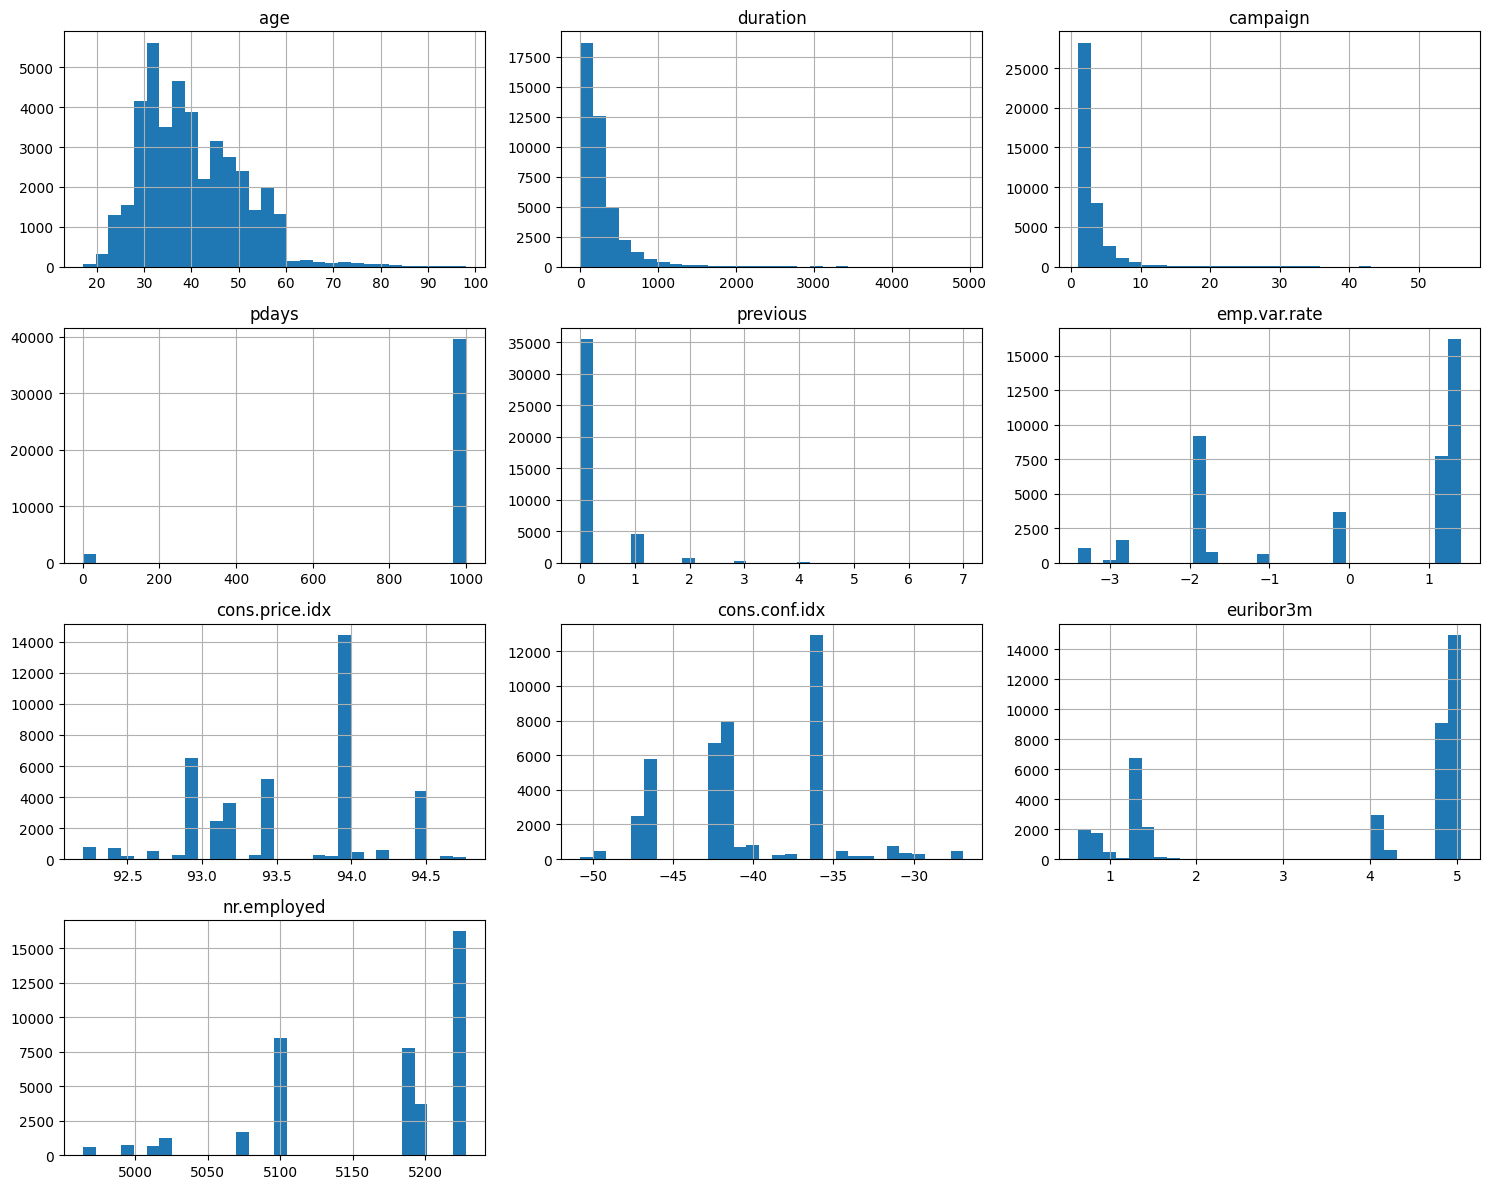

In [ ]:
numerical_cols= df.select_dtypes(include='number').columns
df[numerical_cols].hist(figsize=(15,12),bins=30)

plt.tight_layout()
plt.show()

#NUMERICAL VARIABLE DISTRIBUTION
Histograms is plotted for all numerical variables to understand the distributions.
"age" is mainly concentrated around middle aged customers.
"duration","campaign" and "previous " are highly concentrated at lower values.
"pdays" has a large concentration at 999, which represents customers who were not previously contacted.
The economic variable("emp.var.rate", "cons.price.idx", "cons.conf.idx","euribor3m", and nr.employed) have relatively limited and concentrated values.

#CALCULATING CORRELATION

In [10]:


numerical_columns=['age','duration','campaign','pdays','previous','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']

numerical_df= df[numerical_columns]

In [12]:
correlation= numerical_df.corr()
correlation

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,-0.000808,0.004622,-0.034381,0.024379,-0.000242,0.001009,0.129075,0.010852,-0.017607
duration,-0.000808,1.000000,-0.071765,-0.047556,0.020600,-0.027941,0.005303,-0.008126,-0.032861,-0.044672
campaign,0.004622,-0.071765,1.000000,0.052606,-0.079182,0.150786,0.127826,-0.013657,0.135169,0.144129
pdays,-0.034381,-0.047556,0.052606,1.000000,-0.587508,0.271063,0.078920,-0.091374,0.296946,0.372659
previous,0.024379,0.020600,-0.079182,-0.587508,1.000000,-0.420587,-0.203197,-0.050929,-0.454571,-0.501411
emp.var.rate,-0.000242,-0.027941,0.150786,0.271063,-0.420587,1.000000,0.775293,0.196257,0.972244,0.906949
cons.price.idx,0.001009,0.005303,0.127826,0.078920,-0.203197,0.775293,1.000000,0.059170,0.688180,0.521945
cons.conf.idx,0.129075,-0.008126,-0.013657,-0.091374,-0.050929,0.196257,0.059170,1.000000,0.277864,0.100679
euribor3m,0.010852,-0.032861,0.135169,0.296946,-0.454571,0.972244,0.688180,0.277864,1.000000,0.945146
nr.employed,-0.017607,-0.044672,0.144129,0.372659,-0.501411,0.906949,0.521945,0.100679,0.945146,1.000000


#CORRELATION HEATMAP

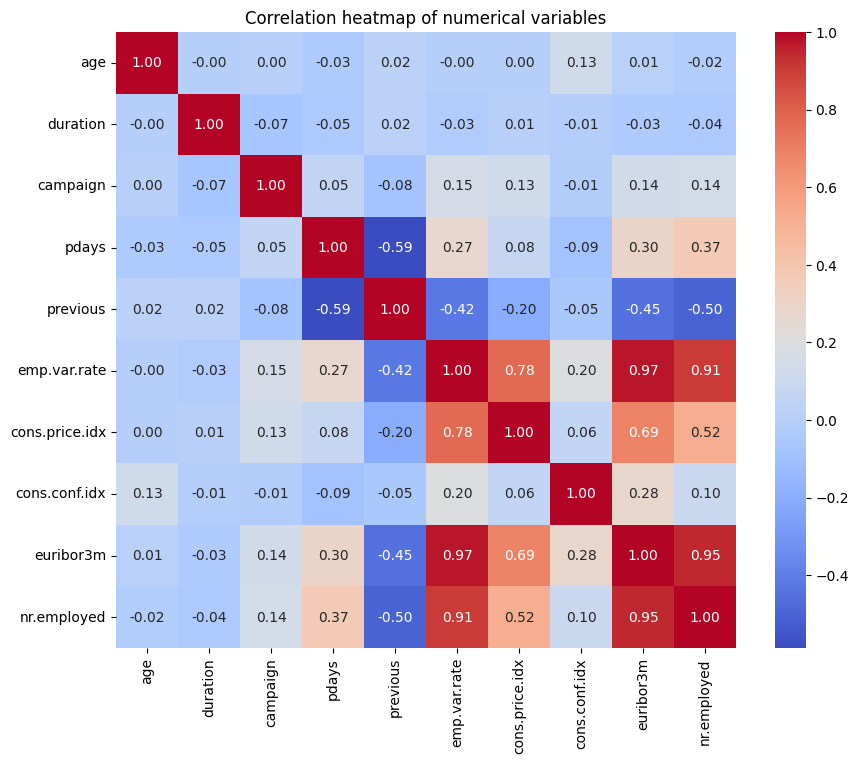

In [13]:

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation heatmap of numerical variables')
plt.show()


#EXPLANATION
The correlation heatmap reveals that most variables have low to moderate correlation with each other,indicating that the features provide distinct information about customer behaviour. This diversity of features is essential for predictive modeling because it allows machine learning algorithms to capture multiple aspectsof customer profile.

#ENCODING TARGET VARIABLE

In [14]:
df['y'].map({'no': 0, 'yes': 1})

,y
0,0
1,0
2,0
3,0
4,0
...,...
41183,1
41184,0
41185,0
41186,1


#ENCODING CATEGORICAL VARIABLE

In [49]:
categorical_cols=['job','marital','education','default','housing','loan','contact','month','day_of_week','poutcome']

In [50]:
df_encoded=df.copy()

In [51]:
df_encoded['y'] = df_encoded['y'].map({'no': 0, 'yes': 1})

print(df_encoded['y'].unique())

[0 1]


In [52]:
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

print(y.unique())

[0 1]


In [53]:
df_ml=df.copy()
df_ml['y'] =df_ml['y'].map({'no': 0, 'yes': 1})


df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True ,
    dtype=int
)

In [54]:
df_encoded.shape

(41176, 54)

In [31]:
df_encoded.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,1,0,0,0,1,0,0,0,1,0
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,1,0,0,0,1,0,0,0,1,0
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,1,0,0,0,1,0,0,0,1,0
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,1,0,0,0,1,0,0,0,1,0
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,1,0,0,0,1,0,0,0,1,0


In [32]:
df_encoded.columns

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'marital_unknown',
       'education_basic.6y', 'education_basic.9y', 'education_high.school',
       'education_illiterate', 'education_professional.course',
       'education_university.degree', 'education_unknown', 'default_unknown',
       'default_yes', 'housing_unknown', 'housing_yes', 'loan_unknown',
       'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul',
       'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct',
       'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue',
       'day_of_week_wed', 'poutcome_nonexistent', 'poutc

#TRAIN-TEST SPLIT


In [33]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(y_train.unique())
print(y_test.unique())

[0 1]
[0 1]


In [34]:
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(32940, 20)
(8236, 20)
y
0    0.887341
1    0.112659
Name: proportion, dtype: float64
y
0    0.887324
1    0.112676
Name: proportion, dtype: float64


In [35]:
print(X_train.shape)
print(X_test.shape)

(32940, 20)
(8236, 20)


In [36]:
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0


## Logistic Regression

Feature scaling

In [84]:
df_encoded=df.copy()
df_encoded['y'] = df_encoded['y'].map({'no': 0 ,'yes': 1})

In [85]:
df_encoded =pd.get_dummies(
    df_encoded,
    columns=categorical_cols,
    drop_first=True
)

In [59]:
df_encoded.dtypes

,0
age,int64
duration,int64
campaign,int64
pdays,int64
previous,int64
emp.var.rate,float64
cons.price.idx,float64
cons.conf.idx,float64
euribor3m,float64
nr.employed,float64


In [83]:
from sklearn.model_selection import train_test_split

x = df_encoded.drop('y', axis=1)
y = df_encoded['y']

X_train, X_test, y_train, y_test=train_test_split(
    x,y, test_size=0.2 , random_state=42
)

In [61]:
X_train.select_dtypes(include='object').columns

Index([], dtype='object')

In [62]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Model training

In [63]:

from sklearn.linear_model import LogisticRegression

balanced_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

balanced_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

#PREDICT

In [68]:

final_predictions = balanced_model.predict(X_test_scaled)

print(final_predictions[:20])

[1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [67]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [69]:
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [70]:
y_pred = model.predict(X_test_scaled)

#EVALUATE ORIGINAL MODEL

In [71]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[7064  201]
 [ 576  395]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7265
           1       0.66      0.41      0.50       971

    accuracy                           0.91      8236
   macro avg       0.79      0.69      0.73      8236
weighted avg       0.89      0.91      0.90      8236



In [76]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy %:", accuracy * 100)

Accuracy: 0.9056580864497329
Accuracy %: 90.56580864497329


#Confusion Matrix + Classification Report

In [75]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, final_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_predictions))

print("\nClassification Report:")
print(classification_report(y_test, final_predictions))

Accuracy: 0.855148130160272

Confusion Matrix:
[[6196 1069]
 [ 124  847]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      7265
           1       0.44      0.87      0.59       971

    accuracy                           0.86      8236
   macro avg       0.71      0.86      0.75      8236
weighted avg       0.92      0.86      0.87      8236



#BALANCED MODEL

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

balanced_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

balanced_model.fit(X_train_scaled, y_train)

y_pred_balanced = balanced_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

Accuracy: 0.855148130160272

Confusion Matrix:
[[6196 1069]
 [ 124  847]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      7265
           1       0.44      0.87      0.59       971

    accuracy                           0.86      8236
   macro avg       0.71      0.86      0.75      8236
weighted avg       0.92      0.86      0.87      8236



## Comparing Both Logistic Regression models

In [77]:


from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Final Balanced Logistic Regression")
print("Accuracy:", accuracy_score(y_test, final_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_predictions))

print("\nClassification Report:")
print(classification_report(y_test, final_predictions))

Final Balanced Logistic Regression
Accuracy: 0.855148130160272

Confusion Matrix:
[[6196 1069]
 [ 124  847]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      7265
           1       0.44      0.87      0.59       971

    accuracy                           0.86      8236
   macro avg       0.71      0.86      0.75      8236
weighted avg       0.92      0.86      0.87      8236



In [ ]:
final_model = balanced_model

In [ ]:
print(y_train.head())
print(y_train.unique())

36454    0
1233     1
24111    0
15516    0
17916    0
Name: y, dtype: int64
[0 1]


In [78]:
original_model = LogisticRegression(max_iter=1000)

original_model.fit(X_train_scaled, y_train)

y_pred_original = original_model.predict(X_test_scaled)

In [79]:
print("Original Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_original))
print(classification_report(y_test, y_pred_original))

Original Logistic Regression
Accuracy: 0.9056580864497329
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7265
           1       0.66      0.41      0.50       971

    accuracy                           0.91      8236
   macro avg       0.79      0.69      0.73      8236
weighted avg       0.89      0.91      0.90      8236



In [81]:
print('Number of Features:', len(X.columns))
print("Number of cofficients",len(original_model.coef_[0]))

Number of Features: 20
Number of cofficients 53


In [87]:
print(df_encoded.shape)


(41176, 54)


In [88]:
print(df_encoded.drop('y',axis=1).shape)


(41176, 53)


In [92]:
import pandas as pd

# Get feature names
feature_names = df_encoded.drop('y',axis=1).columns

# Get Logistic Regression coefficients
coefficients = original_model.coef_[0]

# Create a dataframe
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute coefficient
feature_importance['Absolute_Coefficient'] = feature_importance['Coefficient'].abs()

feature_importance = feature_importance.sort_values(
    'Absolute_Coefficient',
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Absolute_Coefficient
5,emp.var.rate,-2.252806,2.252806
1,duration,1.244154,1.244154
6,cons.price.idx,0.894459,0.894459
8,euribor3m,0.834567,0.834567
37,contact_telephone,-0.289493,0.289493
43,month_may,-0.260297,0.260297
38,month_aug,0.224157,0.224157
42,month_mar,0.206729,0.206729
52,poutcome_success,0.180729,0.180729
51,poutcome_nonexistent,0.171980,0.171980


#CONCLUSION


*  Some age groups and job categories were more likely to subscribe to the term
   deposit than others.

* Cellular contact worked better than telephone, as the subscription rate  was higher for customers contacted through cellular.

* Call duration and number of contacts had an impact on the subscription result.

* Customers who subscribed generally had longer call durations.

* Customers who had a successful result in a previous campaign were much more likely to subscribe again.

*  From the Logistic Regression model, employment variation rate, call duration, consumer price index, and euribor3m were among the features that had a stronger influence on the prediction.

* The dataset was imbalanced, because most customers did not subscribe. So, instead of looking only at accuracy, I also considered precision, recall, and F1-score.

* After handling the class imbalance, the balanced Logistic Regression model achieved 86.43% accuracy and 91% recall for the “yes” class. This means the model was able to identify most of the customers who actually subscribed.
Overall, this analysis helped me understand customer behavior and campaign performance and showed how machine learning can be used to identify potential customers for future marketing campaigns.



